# ☕ Coffee Sales Analysis
**เป้าหมาย:** วิเคราะห์ยอดขายร้านกาแฟจากไฟล์ `index_1.csv` (และเปรียบเทียบกับ `index_2.csv` ท้าย notebook) หาว่าขายดีช่วงไหน สินค้าอะไรทำเงินสุด และตอบคำถามธุรกิจ


## Step 1: โหลดไลบรารีที่ต้องใช้

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('พร้อมแล้ว!')

พร้อมแล้ว!


## Step 2: อัปโหลดไฟล์ index_1.csv
รัน cell นี้แล้วเลือกไฟล์ `index_1.csv` (ไฟล์หลัก 3,636 แถว)

In [6]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f'โหลดไฟล์ {filename} สำเร็จ มี {len(df)} แถว')

Saving index_1.csv to index_1 (1).csv
Saving index_2.csv to index_2 (1).csv
โหลดไฟล์ index_1 (1).csv สำเร็จ มี 3636 แถว


## Step 3: สำรวจข้อมูลเบื้องต้น

In [7]:
print('ชื่อคอลัมน์:', df.columns.tolist())
print()
df.head()

ชื่อคอลัมน์: ['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name']



,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [8]:
df.info()
print()
print('ค่าว่างในแต่ละคอลัมน์:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB

ค่าว่างในแต่ละคอลัมน์:
date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64


## Step 4: ทำความสะอาด + สร้างคอลัมน์วัน/เวลาที่ต้องใช้
ไฟล์นี้มีแค่ `date` กับ `datetime` เต็มๆ เราจะดึง **ชั่วโมง**, **วันในสัปดาห์**, **เดือน** ออกมาเองจากคอลัมน์ `datetime`

In [9]:
# ลบแถวซ้ำ
before = len(df)
df = df.drop_duplicates()
print(f'ลบแถวซ้ำไป {before - len(df)} แถว เหลือ {len(df)} แถว')

# แปลง datetime ให้เป็น datetime จริง
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = pd.to_datetime(df['date'])

# สร้างคอลัมน์ใหม่จาก datetime
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()   # เช่น Monday, Tuesday
df['month_name'] = df['datetime'].dt.month_name()  # เช่น March, April

# ลบแถวที่ไม่มียอดขาย
df = df.dropna(subset=['money'])
print(f'ข้อมูลพร้อมวิเคราะห์: {len(df)} แถว')
df.head()

ลบแถวซ้ำไป 0 แถว เหลือ 3636 แถว
ข้อมูลพร้อมวิเคราะห์: 3636 แถว


,date,datetime,cash_type,card,money,coffee_name,hour,weekday,month_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,10,Friday,March
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12,Friday,March
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12,Friday,March
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,13,Friday,March
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,13,Friday,March


คำถามที่ 1 — ยอดขายเปลี่ยนไปตามเดือนยังไง?

month_name
March        17036.64
October      13891.16
February     13215.48
September     9988.64
May           9063.42
November      8590.54
December      8237.74
June          7758.76
August        7613.84
July          6915.94
April         6720.56
January       6398.86
Name: money, dtype: float64


/tmp/ipykernel_744/1751776214.py:9: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1751776214.py:9: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1751776214.py:9: UserWarning: Glyph 3639 (\N{THAI CHARACTER SARA UEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1751776214.py:9: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1751776214.py:9: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1751776214.py:9: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1751776214.py:9: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout

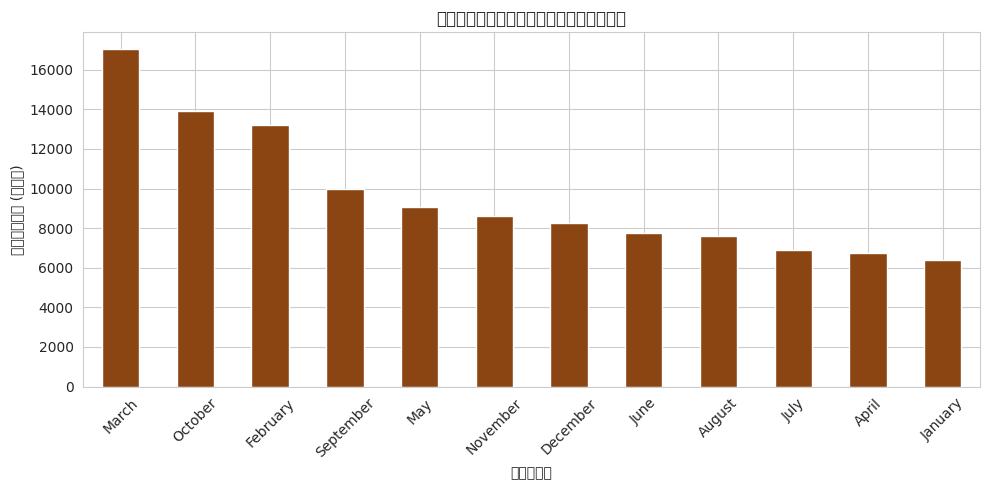

In [10]:
monthly_sales = df.groupby('month_name')['money'].sum().sort_values(ascending=False)
print(monthly_sales)

monthly_sales.plot(kind='bar', color='#8B4513')
plt.title('ยอดขายรวมแต่ละเดือน')
plt.ylabel('ยอดขาย (บาท)')
plt.xlabel('เดือน')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

คำถามที่ 2 — วันไหนในสัปดาห์ขายดีสุด?

/tmp/ipykernel_744/2495030295.py:9: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2495030295.py:9: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2495030295.py:9: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2495030295.py:9: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2495030295.py:9: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2495030295.py:9: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2495030295.py:9: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_l

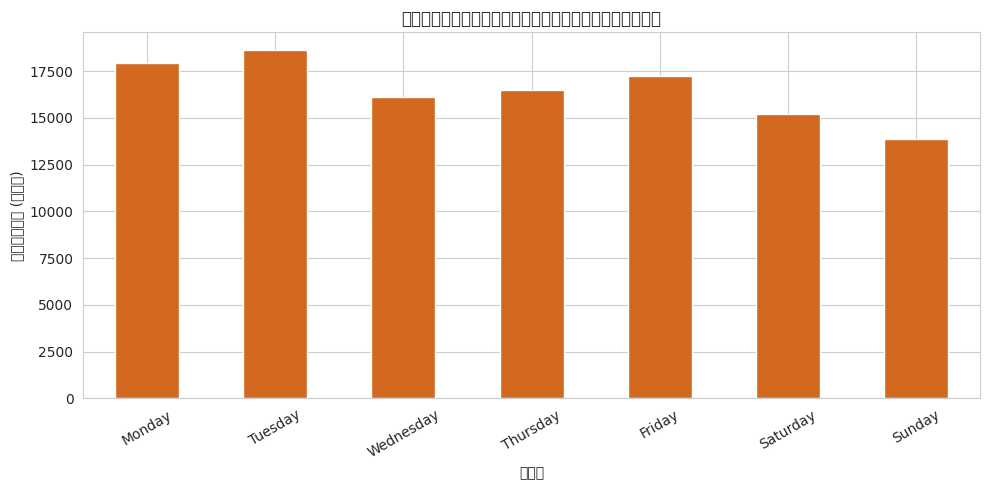

weekday
Monday       17925.10
Tuesday      18637.38
Wednesday    16093.46
Thursday     16477.40
Friday       17257.66
Saturday     15182.52
Sunday       13858.06
Name: money, dtype: float64


In [11]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('weekday')['money'].sum().reindex(weekday_order)

weekday_sales.plot(kind='bar', color='#D2691E')
plt.title('ยอดขายรวมแต่ละวันในสัปดาห์')
plt.ylabel('ยอดขาย (บาท)')
plt.xlabel('วัน')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(weekday_sales)

คำถามที่ 3 — ช่วงเวลาไหนขายดีสุด Peak Hours ?


/tmp/ipykernel_744/2931964758.py:8: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2931964758.py:8: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2931964758.py:8: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2931964758.py:8: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2931964758.py:8: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2931964758.py:8: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2931964758.py:8: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tigh

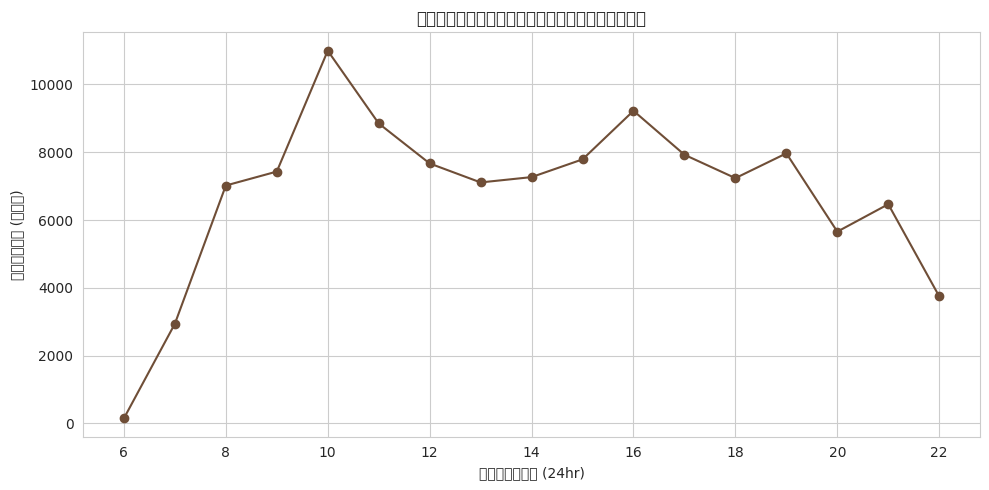

ช่วงเวลาขายดีที่สุด: 10:00 น. (ยอดขาย 10994.52 บาท)


In [17]:
hourly_sales = df.groupby('hour')['money'].sum()

hourly_sales.plot(kind='line', marker='o', color='#6F4E37')
plt.title('ยอดขายตามช่วงเวลาของวัน')
plt.ylabel('ยอดขาย (บาท)')
plt.xlabel('ชั่วโมง (24hr)')
plt.grid(True)
plt.tight_layout()
plt.show()

peak_hour = hourly_sales.idxmax()
print(f'ช่วงเวลาขายดีที่สุด: {peak_hour}:00 น. (ยอดขาย {hourly_sales.max():.2f} บาท)')

คำถามที่ 4 — เมนูไหนขายดีสุด / ทำเงินสุด?

เมนูที่ทำเงินสูงสุด:
coffee_name
Latte                  27866.30
Americano with Milk    25269.12
Cappuccino             18034.14
Americano              15062.26
Hot Chocolate          10172.46
Cocoa                   8678.16
Cortado                 7534.86
Espresso                2814.28
Name: money, dtype: float64


/tmp/ipykernel_744/2085896698.py:9: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2085896698.py:9: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2085896698.py:9: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2085896698.py:9: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2085896698.py:9: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2085896698.py:9: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2085896698.py:9: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layou

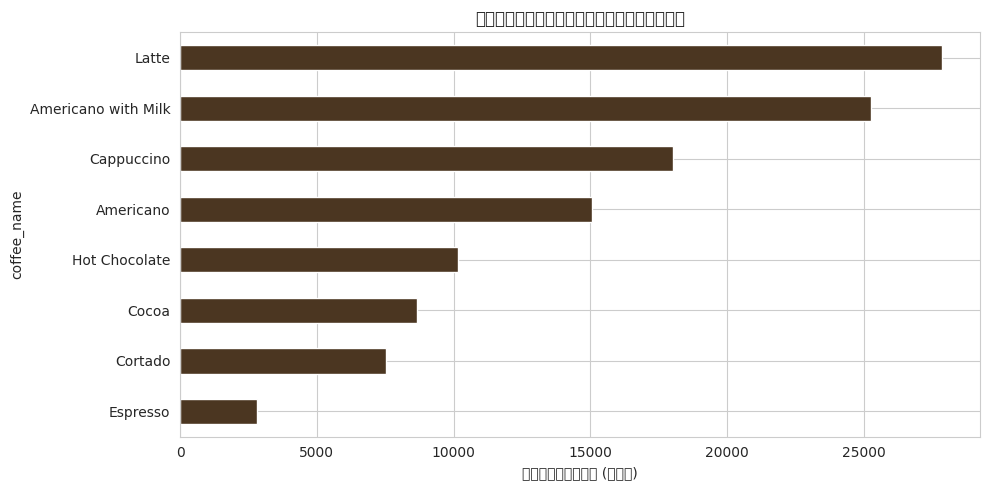


เมนูที่ขายบ่อยที่สุด (จำนวนครั้ง):
coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64


In [13]:
top_revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
print('เมนูที่ทำเงินสูงสุด:')
print(top_revenue)

top_revenue.plot(kind='barh', color='#4B3621')
plt.title('เมนูเรียงตามยอดขายรวม')
plt.xlabel('ยอดขายรวม (บาท)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_count = df['coffee_name'].value_counts()
print()
print('เมนูที่ขายบ่อยที่สุด (จำนวนครั้ง):')
print(top_count)

คำถามที่ 5 — ลูกค้าจ่ายเงินสดหรือบัตรมากกว่ากัน?

           count        sum       mean
cash_type                             
card        3547  112245.58  31.645216
cash          89    3186.00  35.797753


/tmp/ipykernel_744/2292483871.py:7: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2292483871.py:7: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2292483871.py:7: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2292483871.py:7: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2292483871.py:7: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2292483871.py:7: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/2292483871.py:7: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.tight_la

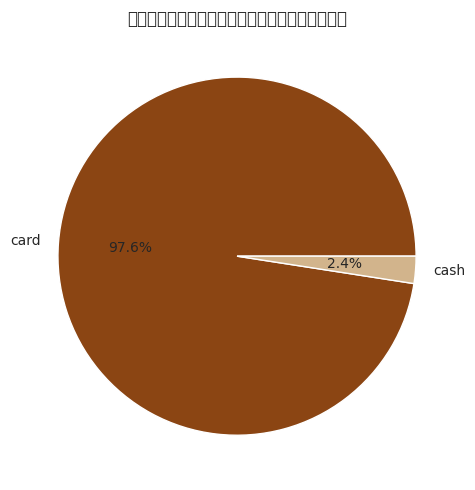

In [14]:
payment_summary = df.groupby('cash_type')['money'].agg(['count', 'sum', 'mean'])
print(payment_summary)

df['cash_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#8B4513', '#D2B48C'])
plt.title('สัดส่วนวิธีการจ่ายเงิน')
plt.ylabel('')
plt.tight_layout()
plt.show()

คำถามที่ 6 ยอดขายเปลี่ยนไปตามช่วงเวลาในหนึ่งปีไหม?

เพราะมีข้อมูลยาวเป็นปี (มี.ค. 2024 - มี.ค. 2025) ลองดูว่ามีฤดูกาล (seasonality) ไหม — ลูกค้าซื้อเยอะช่วงหน้าร้อน/หนาวต่างกันไหม

/tmp/ipykernel_744/1129211323.py:9: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1129211323.py:9: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1129211323.py:9: UserWarning: Glyph 3639 (\N{THAI CHARACTER SARA UEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1129211323.py:9: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1129211323.py:9: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1129211323.py:9: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_744/1129211323.py:9: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

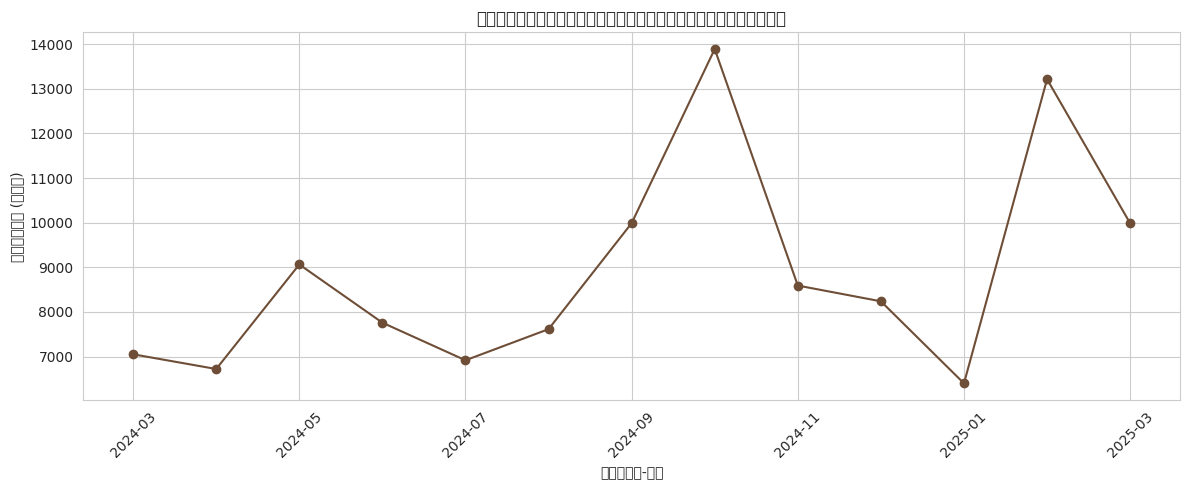

year_month
2024-03     7050.20
2024-04     6720.56
2024-05     9063.42
2024-06     7758.76
2024-07     6915.94
2024-08     7613.84
2024-09     9988.64
2024-10    13891.16
2024-11     8590.54
2024-12     8237.74
2025-01     6398.86
2025-02    13215.48
2025-03     9986.44
Name: money, dtype: float64


In [15]:
df['year_month'] = df['datetime'].dt.to_period('M').astype(str)
trend = df.groupby('year_month')['money'].sum()

trend.plot(kind='line', marker='o', color='#6F4E37', figsize=(12,5))
plt.title('แนวโน้มยอดขายรายเดือนตลอดทั้งปี')
plt.ylabel('ยอดขาย (บาท)')
plt.xlabel('เดือน-ปี')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(trend)

ต้องการ plot ดูเพิ่มว่า จำนวนออเดอร์เพิ่มขึ้น (คนมาซื้อเยอะขึ้น) หรือ ราคาเฉลี่ยต่อแก้วสูงขึ้น (คนซื้อของแพงขึ้น)?

In [18]:
monthly_orders = df.groupby('year_month').size()
monthly_avg = df.groupby('year_month')['money'].mean()

comparison = pd.DataFrame({
    'total_sales': trend,
    'num_orders': monthly_orders,
    'avg_per_order': monthly_avg
})
print(comparison)

            total_sales  num_orders  avg_per_order
year_month                                        
2024-03         7050.20         206      34.224272
2024-04         6720.56         196      34.288571
2024-05         9063.42         267      33.945393
2024-06         7758.76         227      34.179559
2024-07         6915.94         237      29.181181
2024-08         7613.84         272      27.992059
2024-09         9988.64         344      29.036744
2024-10        13891.16         426      32.608357
2024-11         8590.54         259      33.168108
2024-12         8237.74         259      31.805946
2025-01         6398.86         201      31.835124
2025-02        13215.48         423      31.242270
2025-03         9986.44         319      31.305455


## สรุปผล (Insights)

1. **ยอดขายสูงสุดอยู่ในเดือน** (นับเป็นเดือนที่มีข้อมูลครบ): October 2024 (13,891.16 บาท)
2. **วันที่ขายดีที่สุด** คือวัน Tuesday
3. **ช่วงเวลาขายดีที่สุด (Peak Hour)** คือ 10:00 น. (ยอดขาย 10994.52 บาท)
4. **เมนูขายดีทำเงินดีที่สุด** คือ Latte (27,866.30 บาท)
5. **แนวโน้มตลอดปี:** ยอดขายแกว่งขึ้นลง 2 เท่า เกิดจากลูกค้าและออเดอร์ที่เปลี่ยนไป ราคาเฉลี่ยต่อแก้วค่อนข้างคงที่ตลอดทั้งปี จำนวนคนเข้าร้านคือจุดที่ขับเคลื่อนยอดขาย


เปรียบเทียบกับ index_2.csv (ร้าน/เมนูอีกชุดนึง)

`index_2.csv` มีเมนูหลากหลายกว่า (30 เมนู รวมเครื่องดื่มผสม whiskey) แต่มีข้อมูลแค่ 262 แถว ช่วง ก.พ.-มี.ค. 2025 ลองเทียบยอดขายเฉลี่ยต่อออเดอร์ดูว่าต่างจาก index_1 ไหม

In [20]:
uploaded2 = files.upload()
filename2 = [f for f in uploaded2.keys() if 'index_2' in f][0]
df2 = pd.read_csv(filename2)
df2['datetime'] = pd.to_datetime(df2['datetime'])

print(f'index_2: {len(df2)} แถว, ยอดขายเฉลี่ยต่อออเดอร์ = {df2["money"].mean():.2f} บาท')
print(f'index_1: {len(df)} แถว, ยอดขายเฉลี่ยต่อออเดอร์ = {df["money"].mean():.2f} บาท')

comparison = pd.DataFrame({
    'dataset': ['index_1', 'index_2'],
    'avg_order_value': [df['money'].mean(), df2['money'].mean()],
    'num_orders': [len(df), len(df2)],
    'unique_menu_items': [df['coffee_name'].nunique(), df2['coffee_name'].nunique()]
})
print(comparison)

Saving index_2.csv to index_2 (4).csv
index_2: 262 แถว, ยอดขายเฉลี่ยต่อออเดอร์ = 26.30 บาท
index_1: 3636 แถว, ยอดขายเฉลี่ยต่อออเดอร์ = 31.75 บาท
   dataset  avg_order_value  num_orders  unique_menu_items
0  index_1        31.746859        3636                  8
1  index_2        26.297710         262                 30


**สรุป** :
ยอดขายเฉลี่ยต่อออเดอร์ของ  index_2.csv ต่ำกว่า index_1 ทั้งที่มีเมนูราคาถูกจำนวนมากใน index_2 (เช่น Tea, Chocolate ธรรมดา) ปนกับเมนูราคาแพง (whiskey-based drinks) ทำให้ค่าเฉลี่ยรวมออกมาต่ำกว่า ทั้งที่มีตัวเลือกพรีเมียมมากกว่า